In [ ]:
## DESEQ2 normal tissue vs RA tissue

In [ ]:
pip install pydeseq2

In [ ]:
pip install pandas

In [ ]:
import pandas as pd

In [ ]:
rheum = pd.read_csv("/content/sample_data/GSE89408_raw_RNA-seq_counts.csv")

In [ ]:
rheum.head()

,Unnamed: 0,normal_tissue_1,normal_tissue_2,normal_tissue_3,normal_tissue_4,normal_tissue_5,normal_tissue_6,normal_tissue_7,normal_tissue_8,normal_tissue_9,...,RA_tissue_143,RA_tissue_144,RA_tissue_145,RA_tissue_146,RA_tissue_147,RA_tissue_148,RA_tissue_149,RA_tissue_150,RA_tissue_151,RA_tissue_152
0,5S_rRNA,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.00,0.0,...,0.0,0.00,1.00,1.0,1.00,1.00,0.00,0.00,1.00,0.00
1,7SK,472.59,897.97,1127.7,441.8,363.9,291.5,1032.7,670.37,0.0,...,2250.2,3708.41,1335.70,2533.7,1960.84,3278.89,1094.61,3539.28,1145.43,1164.43
2,7SK:ENSG00000260682,17.41,37.03,89.3,27.2,78.1,118.5,64.3,69.63,0.0,...,156.8,116.59,93.30,125.3,123.16,123.11,115.39,93.72,105.57,117.57
3,A1BG,45.00,15.00,19.0,29.0,32.0,15.0,19.0,39.00,43.0,...,12.0,29.00,15.00,27.0,30.00,28.24,45.00,40.00,55.00,15.00
4,A1BG-AS1,96.00,13.00,25.0,99.0,80.0,70.0,59.0,105.00,0.0,...,34.0,42.00,9.03,89.0,71.00,62.00,103.00,83.00,170.00,57.00


In [ ]:
rheum.columns

Index(['Unnamed: 0', 'normal_tissue_1', 'normal_tissue_2', 'normal_tissue_3',
       'normal_tissue_4', 'normal_tissue_5', 'normal_tissue_6',
       'normal_tissue_7', 'normal_tissue_8', 'normal_tissue_9',
       ...
       'RA_tissue_143', 'RA_tissue_144', 'RA_tissue_145', 'RA_tissue_146',
       'RA_tissue_147', 'RA_tissue_148', 'RA_tissue_149', 'RA_tissue_150',
       'RA_tissue_151', 'RA_tissue_152'],
      dtype='object', length=219)

In [ ]:
control_samples = [col for col in rheum.columns if 'normal_tissue' in col]
treat_samples = [col for col in rheum.columns if 'RA_tissue' in col]

print("Control Tissue:")
for sample in control_samples:
    print(sample)

print("\nTreat Tissue:")
for sample in treat_samples:
    print(sample)

Control Tissue:
normal_tissue_1
normal_tissue_2
normal_tissue_3
normal_tissue_4
normal_tissue_5
normal_tissue_6
normal_tissue_7
normal_tissue_8
normal_tissue_9
normal_tissue_10
normal_tissue_11
normal_tissue_12
normal_tissue_13
normal_tissue_14
normal_tissue_15
normal_tissue_16
normal_tissue_17
normal_tissue_18
normal_tissue_19
normal_tissue_20
normal_tissue_21
normal_tissue_22
normal_tissue_23
normal_tissue_24
normal_tissue_25
normal_tissue_26
normal_tissue_27
normal_tissue_28

Treat Tissue:
RA_tissue_1
RA_tissue_2
RA_tissue_3
RA_tissue_4
RA_tissue_5
RA_tissue_6
RA_tissue_7
RA_tissue_8
RA_tissue_9
RA_tissue_10
RA_tissue_11
RA_tissue_12
RA_tissue_13
RA_tissue_14
RA_tissue_15
RA_tissue_16
RA_tissue_17
RA_tissue_18
RA_tissue_19
RA_tissue_20
RA_tissue_21
RA_tissue_22
RA_tissue_23
RA_tissue_24
RA_tissue_25
RA_tissue_26
RA_tissue_27
RA_tissue_28
RA_tissue_29
RA_tissue_30
RA_tissue_31
RA_tissue_32
RA_tissue_33
RA_tissue_34
RA_tissue_35
RA_tissue_36
RA_tissue_37
RA_tissue_38
RA_tissue_39
RA_t

In [ ]:
all_samples = control_samples + treat_samples
conditions = ['normal_tissue'] * len(control_samples) + ['RA_tissue'] * len(treat_samples)

metadata = pd.DataFrame({
    'condition': conditions
}, index=all_samples)

print("Metadata DataFrame head:")
display(metadata.head())

Metadata DataFrame head:


,condition
normal_tissue_1,normal_tissue
normal_tissue_2,normal_tissue
normal_tissue_3,normal_tissue
normal_tissue_4,normal_tissue
normal_tissue_5,normal_tissue


In [ ]:
counts_df = rheum[all_samples].round().astype(int)

print("Prepared Count Data head:")
display(counts_df.head())

Prepared Count Data head:


,normal_tissue_1,normal_tissue_2,normal_tissue_3,normal_tissue_4,normal_tissue_5,normal_tissue_6,normal_tissue_7,normal_tissue_8,normal_tissue_9,normal_tissue_10,...,RA_tissue_143,RA_tissue_144,RA_tissue_145,RA_tissue_146,RA_tissue_147,RA_tissue_148,RA_tissue_149,RA_tissue_150,RA_tissue_151,RA_tissue_152
0,0,0,0,0,0,0,0,0,0,0,...,0,0,1,1,1,1,0,0,1,0
1,473,898,1128,442,364,292,1033,670,0,510,...,2250,3708,1336,2534,1961,3279,1095,3539,1145,1164
2,17,37,89,27,78,118,64,70,0,30,...,157,117,93,125,123,123,115,94,106,118
3,45,15,19,29,32,15,19,39,43,105,...,12,29,15,27,30,28,45,40,55,15
4,96,13,25,99,80,70,59,105,0,129,...,34,42,9,89,71,62,103,83,170,57


In [ ]:
from pydeseq2.dds import DeseqDataSet
from pydeseq2.default_inference import DefaultInference

inference = DefaultInference()
dds = DeseqDataSet(
    counts=counts_df.T, # Transpose counts_df here
    metadata=metadata,
    design_factors=["condition"],
    inference=inference,
)

print("DeseqDataSet object initialized successfully.")
dds

DeseqDataSet object initialized successfully.


/usr/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/tmp/ipykernel_15013/2239783494.py:5: DeprecationWarning: design_factors is deprecated and will soon be removed.Please consider providing a formulaic formula using the design argumentinstead.
  dds = DeseqDataSet(


AnnData object with n_obs × n_vars = 180 × 25049
    obs: 'condition'
    obsm: 'design_matrix'

In [ ]:
dds.var_names_make_unique()
dds.deseq2()

print("DESeq2 analysis completed successfully.")

Fitting size factors...


Using None as control genes, passed at DeseqDataSet initialization


... done in 0.37 seconds.

Fitting dispersions...


In [ ]:
from pydeseq2.ds import DeseqStats

stat_res = DeseqStats(dds, contrast=["condition", "RA_tissue", "normal_tissue"])
stat_res.summary()

print("Differential expression analysis summary:")
display(stat_res.results_df.head())

In [ ]:
stat_res.results_df.to_csv("RA_results.csv")

In [ ]:
genes_to_remove = [
    'AK128525', 'immunoglobulin_heavy_chain', 'Ig_kappa', 'DKFZp667J0810',
    'abParts', 'C11orf95:ENSG00000188070', 'RP4-535B20.1:ENSG00000231485'
]

significant_genes = stat_res.results_df[
    (stat_res.results_df['baseMean'] > 10) &
    (stat_res.results_df['log2FoldChange'].abs() > 1) &
    (stat_res.results_df['padj'] < 0.05) &
    (~stat_res.results_df.index.isin(genes_to_remove)) # Exclude specified genes
].sort_values('padj')

print("Significantly differentially expressed genes (filtered after removal):")
display(significant_genes.head())

In [ ]:
significant_genes

In [ ]:
top_20_upregulated = significant_genes[significant_genes['log2FoldChange'] > 0].sort_values(by='log2FoldChange', ascending=False).head(20)

print("\nTop 20 Upregulated Genes (after removal):")
display(top_20_upregulated)

In [ ]:
top_20_downregulated = significant_genes[significant_genes['log2FoldChange'] < 0].sort_values(by='log2FoldChange', ascending=True).head(20)

print("\nTop 20 Downregulated Genes (after removal):")
display(top_20_downregulated)

In [ ]:
pip install matplotlib

Fit type used for VST : parametric
Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.53 seconds.

Fitting dispersions...
... done in 55.18 seconds.



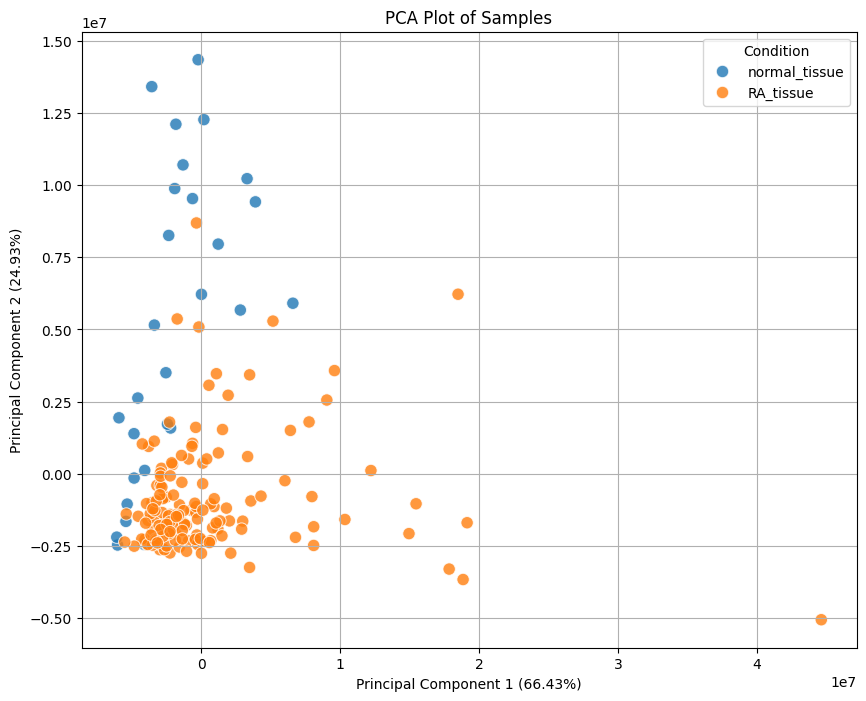

In [69]:
#PCA

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
import pandas as pd

# Compute VST. The dds.vst() method modifies the dds object in-place.
dds.vst()

# Extract the variance-stabilized transformed (VST) counts.
# Based on the KeyError, dds.layers['vst'] was not populated.
# A common alternative for AnnData objects after transformations
# is that the transformed data is in dds.X.
vst_counts = dds.X

# Perform PCA
pca = PCA(n_components=2) # Get the first two principal components
pca_result = pca.fit_transform(vst_counts)

# Create a DataFrame for plotting
pca_df = pd.DataFrame(data=pca_result, columns=['PC1', 'PC2'], index=dds.obs_names)

# Add metadata (e.g., 'condition') to the PCA DataFrame
pca_df = pca_df.merge(metadata[['condition']], left_index=True, right_index=True)

# Plotting the PCA results
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='condition',
    data=pca_df,
    s=80, # Size of points
    alpha=0.8
)

plt.title('PCA Plot of Samples')
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.2f}%)')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.2f}%)')
plt.grid(True)
plt.legend(title='Condition')
plt.show()

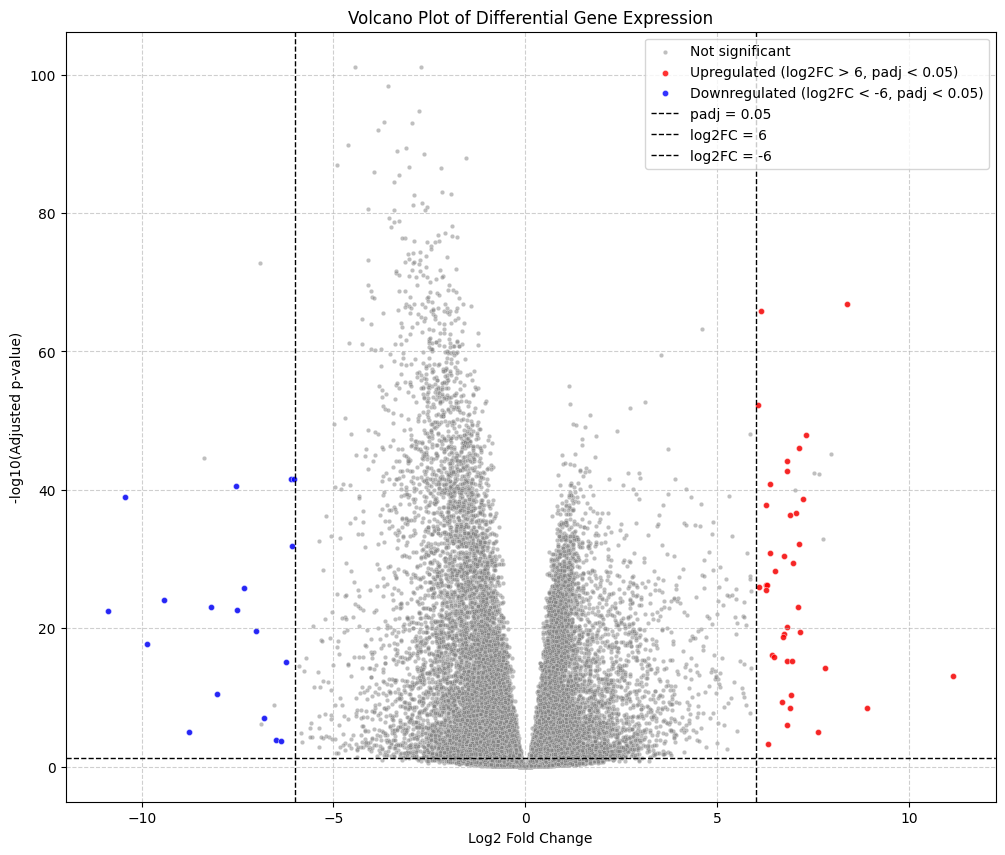

In [119]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Define thresholds
log2fc_threshold = 6
padj_threshold = 0.05

# Create a column for -log10(padj) for easier plotting in the full results DataFrame
stat_res.results_df['-log10_padj'] = -np.log10(stat_res.results_df['padj'])

# Ensure significant_genes also has the -log10_padj column for highlighting
if '-log10_padj' not in significant_genes.columns:
    # Make a copy to avoid SettingWithCopyWarning if significant_genes is a view
    significant_genes = significant_genes.copy()
    significant_genes['-log10_padj'] = -np.log10(significant_genes['padj'])

plt.figure(figsize=(12, 10))
sns.scatterplot(
    x='log2FoldChange',
    y='-log10_padj',
    data=stat_res.results_df,
    color='gray',
    alpha=0.5,
    s=10,
    label='Not significant'
)

# Highlight significant upregulated genes
sns.scatterplot(
    x='log2FoldChange',
    y='-log10_padj',
    data=significant_genes[significant_genes['log2FoldChange'] > log2fc_threshold],
    color='red',
    alpha=0.8,
    s=20,
    label=f'Upregulated (log2FC > {log2fc_threshold}, padj < {padj_threshold})'
)

# Highlight significant downregulated genes
sns.scatterplot(
    x='log2FoldChange',
    y='-log10_padj',
    data=significant_genes[significant_genes['log2FoldChange'] < -log2fc_threshold],
    color='blue',
    alpha=0.8,
    s=20,
    label=f'Downregulated (log2FC < -{log2fc_threshold}, padj < {padj_threshold})'
)

# Add threshold lines
plt.axhline(-np.log10(padj_threshold), color='black', linestyle='--', linewidth=1, label=f'padj = {padj_threshold}')
plt.axvline(log2fc_threshold, color='black', linestyle='--', linewidth=1, label=f'log2FC = {log2fc_threshold}')
plt.axvline(-log2fc_threshold, color='black', linestyle='--', linewidth=1, label=f'log2FC = -{log2fc_threshold}')

plt.title('Volcano Plot of Differential Gene Expression')
plt.xlabel('Log2 Fold Change')
plt.ylabel('-log10(Adjusted p-value)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [ ]:
#Heatmap

In [74]:
res = significant_genes

In [97]:
res

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,-log10_padj
Unnamed: 0,,,,,,,
CROCC,1772.594252,-4.448346,0.203180,-21.893587,2.990314e-106,7.488943e-102,101.125579
SURF6,633.396044,-2.714759,0.124186,-21.860345,6.197341e-106,7.760311e-102,101.110121
ZNF444,160.209637,-3.590117,0.166573,-21.552859,4.977659e-103,4.155349e-99,98.381392
PELP1,658.463881,-2.775909,0.131250,-21.149710,2.776456e-99,1.738339e-95,94.759865
SCRIB,1036.729965,-3.688326,0.175938,-20.963828,1.403360e-97,7.029147e-94,93.153097
...,...,...,...,...,...,...,...
HSPA1A,130.321838,-1.327162,0.607776,-2.183637,2.898896e-02,4.371384e-02,1.359381
UNC13C,20.781666,1.094513,0.505773,2.164040,3.046132e-02,4.580720e-02,1.339066
NCMAP,18.105102,1.032030,0.481174,2.144817,3.196748e-02,4.791391e-02,1.319538


In [164]:
# Log2foldchange greater or lower than 0.5
sigs = res[(res.padj < 0.05) & (abs(res.log2FoldChange) > 2)]

In [165]:
sigs.shape[0]

2008

In [135]:
dds.layers['normed_counts']

array([[0.00000000e+00, 6.24487771e+02, 2.24445922e+01, ...,
        3.77333203e+03, 4.97609812e+03, 5.26787781e+02],
       [0.00000000e+00, 1.23520991e+03, 5.08939494e+01, ...,
        4.56670032e+02, 4.85555787e+03, 2.17330919e+03],
       [0.00000000e+00, 8.80594228e+02, 6.94795091e+01, ...,
        1.11791750e+03, 3.49115017e+03, 1.36148611e+03],
       ...,
       [0.00000000e+00, 2.56875024e+03, 6.82290260e+01, ...,
        1.57580016e+03, 2.60939732e+03, 1.48507008e+03],
       [5.90731025e-01, 6.76387023e+02, 6.26174886e+01, ...,
        1.20509129e+03, 2.72563295e+03, 1.55244113e+03],
       [0.00000000e+00, 8.52834244e+02, 8.64557052e+01, ...,
        4.57189492e+02, 2.23392750e+03, 2.08299635e+03]])

In [136]:
#Getting log of normalized counts
dds.layers['log1p'] = np.log1p(dds.layers['normed_counts'])
dds.layers['log1p']

array([[0.        , 6.43853178, 3.15463986, ..., 8.2359787 , 8.51260229,
        6.26869427],
       [0.        , 7.11980545, 3.9492022 , ..., 6.12614847, 8.48808521,
        7.68446628],
       [0.        , 6.78173189, 4.25532202, ..., 7.02011697, 8.15827292,
        7.21706633],
       ...,
       [0.        , 7.85156399, 4.23742023, ..., 7.36315286, 7.86725772,
        7.30389038],
       [0.46419367, 6.51824278, 4.15288841, ..., 7.09514007, 7.91082277,
        7.34822783],
       [0.        , 6.74973708, 4.47113244, ..., 6.12728284, 7.71196407,
        7.64204265]])

In [137]:
#Filtering the dds object to retain only the significant genes
dds_sigs = dds[:, sigs.index]
dds_sigs

View of AnnData object with n_obs × n_vars = 180 × 57
    obs: 'condition', 'size_factors', 'replaceable'
    var: '_normed_means', 'non_zero', '_MoM_dispersions', 'genewise_dispersions', '_genewise_converged', 'fitted_dispersions', 'MAP_dispersions', '_MAP_converged', 'dispersions', '_outlier_genes', '_LFC_converged', 'replaced', 'refitted', '_pvalue_cooks_outlier', 'vst_genewise_dispersions'
    uns: 'trend_coeffs', 'disp_function_type', '_squared_logres', 'prior_disp_var', 'vst_trend_coeffs'
    obsm: 'design_matrix', '_mu_LFC', '_hat_diagonals'
    varm: 'LFC'
    layers: 'normed_counts', '_mu_hat', 'cooks', 'replace_cooks', '_vst_mu_hat', 'vst_counts', 'log1p'

In [138]:
# Making a dataframe for ploting
grapher = pd.DataFrame(dds_sigs.layers['log1p'].T,
                       index=dds_sigs.var_names, columns=dds_sigs.obs_names)

/usr/local/lib/python3.12/dist-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


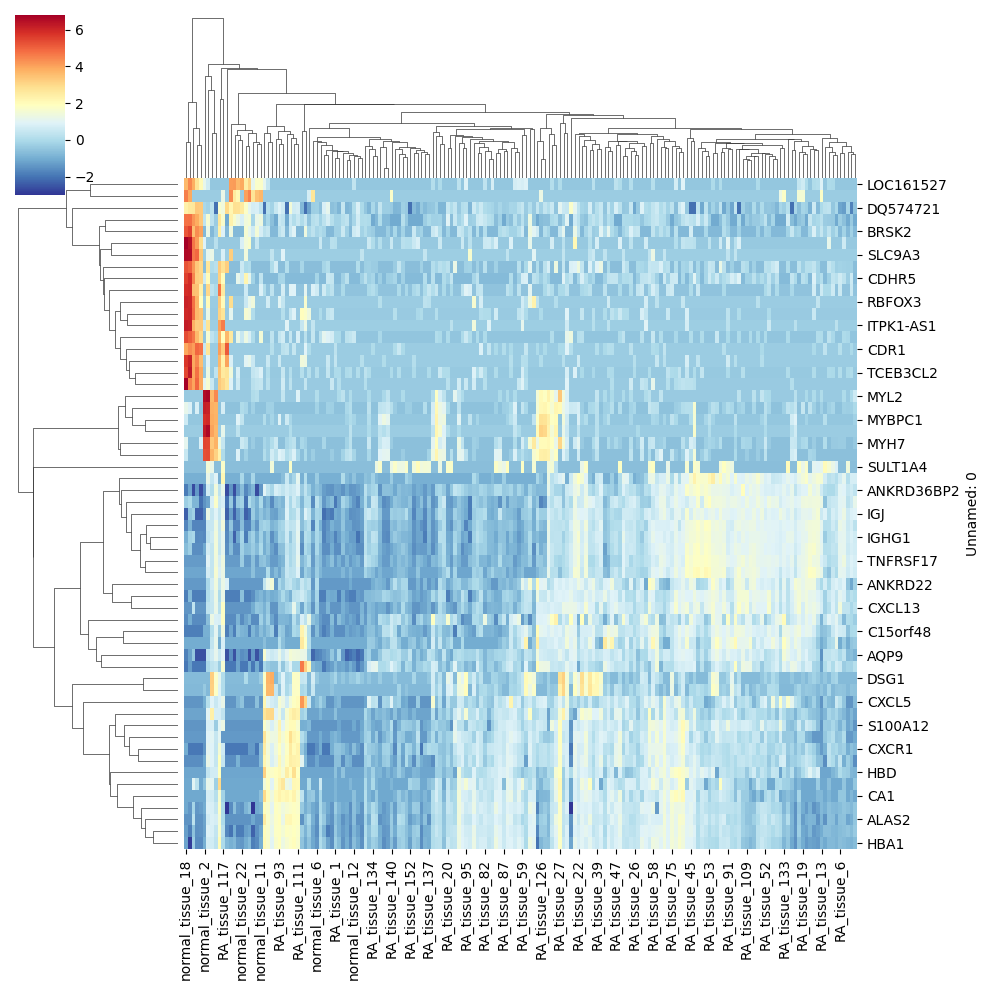

In [139]:
sns.clustermap(grapher, z_score=0, cmap = 'RdYlBu_r')